In [1]:
import os

os.makedirs("self_cooperation_rates", exist_ok=True)

In [2]:
import axelrod as axl
import numpy as np
from agents.aif.joint_state import AIFJointAgent, SlowLearnAIF, FastLearnAIF, StdLearnAIF
from agents.aif.joint_state import AIFJointAgent, SlowLearnAIF_P2, FastLearnAIF_P2, StdLearnAIF_P2
from agents.aif.joint_state import CustomAIF, SlowLearnAIFNoiseAware, FastLearnAIFNoiseAware, StdLearnAIFNoiseAware 
from agents.aif.factorized import Factorized
from agents.aif.jax.five_state import JaxFiveStateAgent
from agents.aif.jax.five_state_noise import JaxFiveStateAgentNoisy
from agents.aif.jax.factorized import JaxFactorizedAgent




# Generate noise levels from 0 to 0.5 at 0.05 intervals
noise_levels = list(np.arange(0, 0.55, 0.05).round(2))

strategies = [
    axl.Cooperator,
    axl.Defector,
    axl.TitForTat,
    axl.Random,
    axl.GTFT,
    axl.Grudger,
    axl.ZDExtort4,
    axl.ZDGen2,
    axl.RiskyQLearner,
    axl.ArrogantQLearner,
    axl.CautiousQLearner,
    # axl.EvolvedANNNoise05,
    JaxFiveStateAgent,
    JaxFiveStateAgentNoisy,
    JaxFactorizedAgent,
    axl.DBS,
    axl.APavlov2011,
    axl.WinStayLoseShift
]

for strategy in strategies:
    os.makedirs(f"self_cooperation_rates/{strategy().name}", exist_ok=True)

In [3]:
from tournament.handler import FileSystemHandler
from tournament.tournament import NoiseTournament

# processes = os.cpu_count() - 2
processes = 18
print("Running tournament with", processes, "processes")

for strat in strategies:
    repetitions = 20
    seed = 42
    turns = 1000


    players = [strat()]

    # # 2. Instantiate the handler
    handler = FileSystemHandler(root_dir=f"self_cooperation_rates/{strat.name}")

    # # 3. Instantiate the tournament with the handler's callbacks
    noise_tournament = NoiseTournament(
        players=players,
        noise_levels=noise_levels,
        repetitions=repetitions,
        seed=seed,
        callback=handler.save_results,
        skip_callback=handler.skip_run,
    )

    # # 4. Run the tournament
    noise_tournament.run(turns=turns, processes=processes)

    # print("Test tournament finished.")
    print(f"Results are saved in the '{handler.root_dir}' directory.")

Running tournament with 18 processes


0it [00:00, ?it/s]

Results are saved in the 'self_cooperation_rates/Cooperator' directory.



0it [00:00, ?it/s]

Results are saved in the 'self_cooperation_rates/Defector' directory.


...

Results are saved in the 'self_cooperation_rates/DBS' directory.



0it [00:00, ?it/s]

Results are saved in the 'self_cooperation_rates/Adaptive Pavlov 2011' directory.



0it [00:00, ?it/s]

Results are saved in the 'self_cooperation_rates/Win-Stay Lose-Shift' directory.


In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from cycler import cycler
from matplotlib.colors import hsv_to_rgb

colors = [hsv_to_rgb([(i * 0.618033988749895) % 1.0, 1, 1]) for i in range(1000)]
plt.rc('axes', prop_cycle=(cycler('color', colors)))

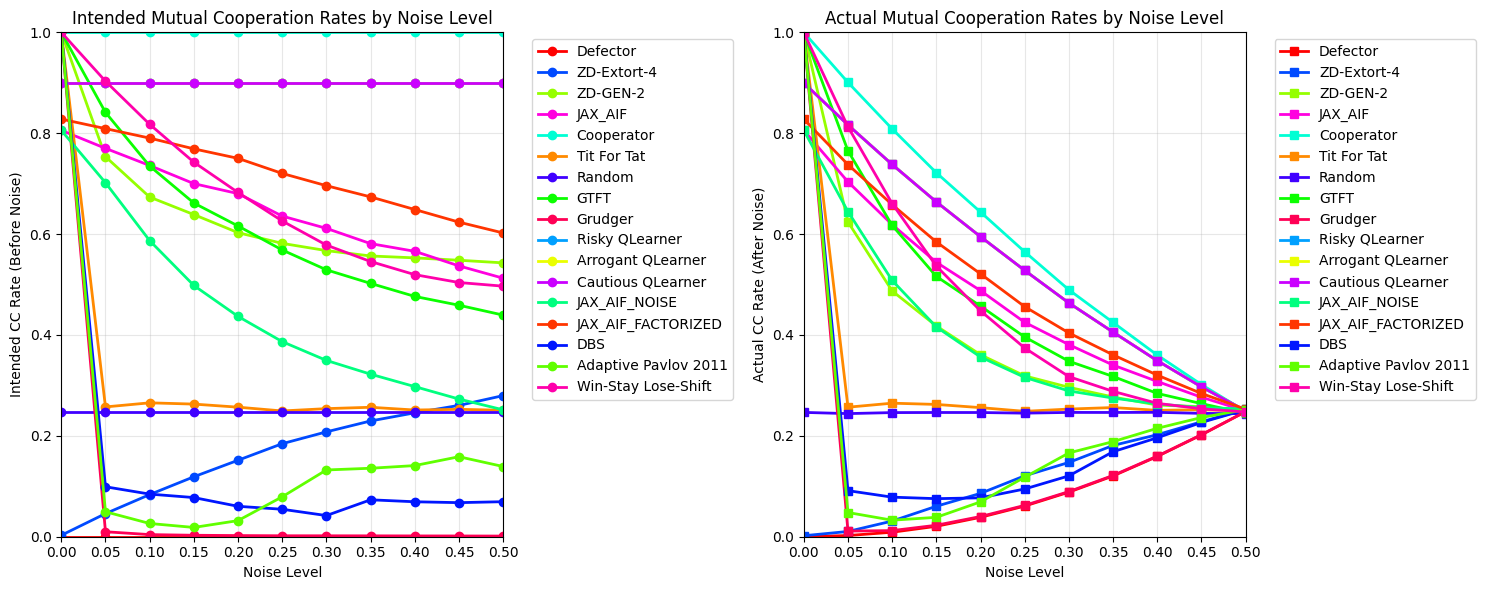

\nSummary Statistics:
Defector            : Intended=0.000, Actual=0.086, Impact=-0.086
ZD-Extort-4         : Intended=0.165, Actual=0.120, Impact=0.044
ZD-GEN-2            : Intended=0.638, Actual=0.414, Impact=0.224
JAX_AIF             : Intended=0.649, Actual=0.467, Impact=0.181
Cooperator          : Intended=1.000, Actual=0.588, Impact=0.412
Tit For Tat         : Intended=0.323, Actual=0.323, Impact=0.001
Random              : Intended=0.247, Actual=0.246, Impact=0.001
GTFT                : Intended=0.621, Actual=0.474, Impact=0.147
Grudger             : Intended=0.094, Actual=0.179, Impact=-0.085
Risky QLearner      : Intended=0.900, Actual=0.546, Impact=0.354
Arrogant QLearner   : Intended=0.900, Actual=0.546, Impact=0.354
Cautious QLearner   : Intended=0.900, Actual=0.546, Impact=0.354
JAX_AIF_NOISE       : Intended=0.446, Actual=0.398, Impact=0.048
JAX_AIF_FACTORIZED  : Intended=0.719, Actual=0.492, Impact=0.228
DBS                 : Intended=0.154, Actual=0.216, Impact=-0.062


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import glob

# Get all strategy directories
strategy_dirs = [d for d in Path("self_cooperation_rates").iterdir() if d.is_dir()]

# strategy_dirs = list(filter(lambda x: x.name.count("AIF") != 0 or x.name.count("Q") != 0, strategy_dirs))
# only load the strategies that arein the list above
strategy_dirs = list(filter(lambda x: x.name in [strat.name for strat in strategies], strategy_dirs))
# Store results for plotting
results = {}

for strategy_dir in strategy_dirs:
    strategy_name = strategy_dir.name
    results[strategy_name] = {'noise_levels': [], 'intended_cc_rates': [], 'actual_cc_rates': []}
    
    for noise_level in noise_levels:
        intended_cc_counts = []
        actual_cc_counts = []
        
        # Get all repetition directories
        repetition_dirs = [d for d in strategy_dir.iterdir() if d.is_dir() and d.name.startswith('repetition_')]
        
        for rep_dir in repetition_dirs:
            csv_file = rep_dir / f"{noise_level}.csv"
            
            if csv_file.exists():
                # Read the CSV file
                df = pd.read_csv(csv_file)
                
                # Get intended actions for both players
                intended_actions_p1 = df.iloc[0]['Intended Actions']
                intended_actions_p2 = df.iloc[1]['Intended Actions']
                
                # Count intended cooperation (CC) - both players cooperate
                intended_cc_count = sum(1 for a1, a2 in zip(intended_actions_p1, intended_actions_p2) 
                                      if a1 == 'C' and a2 == 'C')
                
                # Get actual CC count from the CSV
                actual_cc_count = df.iloc[0]['CC count']  # Same for both rows
                
                intended_cc_counts.append(intended_cc_count / 1000)  # Convert to rate
                actual_cc_counts.append(actual_cc_count / 1000)  # Convert to rate
        
        if intended_cc_counts:  # If we have data for this noise level
            results[strategy_name]['noise_levels'].append(noise_level)
            results[strategy_name]['intended_cc_rates'].append(np.mean(intended_cc_counts))
            results[strategy_name]['actual_cc_rates'].append(np.mean(actual_cc_counts))

# Sort data by noise levels for proper plotting
for strategy_name, data in results.items():
    if data['noise_levels']:
        # Sort all lists by noise levels
        sorted_indices = sorted(range(len(data['noise_levels'])), key=lambda i: data['noise_levels'][i])
        data['noise_levels'] = [data['noise_levels'][i] for i in sorted_indices]
        data['intended_cc_rates'] = [data['intended_cc_rates'][i] for i in sorted_indices]
        data['actual_cc_rates'] = [data['actual_cc_rates'][i] for i in sorted_indices]

# Create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot intended CC rates (before noise)
for strategy_name, data in results.items():
    if data['noise_levels']:  # Only plot if we have data
        ax1.plot(data['noise_levels'], data['intended_cc_rates'], 
                marker='o', label=strategy_name, linewidth=2, markersize=6)

ax1.set_xlabel('Noise Level')
ax1.set_ylabel('Intended CC Rate (Before Noise)')
ax1.set_title('Intended Mutual Cooperation Rates by Noise Level')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)
ax1.set_xlim(0, 0.5)
ax1.set_xticks(np.arange(0, 0.55, 0.05))

# Plot actual CC rates (after noise)
for strategy_name, data in results.items():
    if data['noise_levels']:  # Only plot if we have data
        ax2.plot(data['noise_levels'], data['actual_cc_rates'], 
                marker='s', label=strategy_name, linewidth=2, markersize=6)

ax2.set_xlabel('Noise Level')
ax2.set_ylabel('Actual CC Rate (After Noise)')
ax2.set_title('Actual Mutual Cooperation Rates by Noise Level')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 0.5)
ax2.set_xticks(np.arange(0, 0.55, 0.05))

plt.tight_layout()
plt.show()

# Print summary statistics
print("\\nSummary Statistics:")
print("=" * 50)
for strategy_name, data in results.items():
    if data['noise_levels']:
        intended_mean = np.mean(data['intended_cc_rates'])
        actual_mean = np.mean(data['actual_cc_rates'])
        noise_impact = intended_mean - actual_mean
        print(f"{strategy_name:20s}: Intended={intended_mean:.3f}, Actual={actual_mean:.3f}, Impact={noise_impact:.3f}")


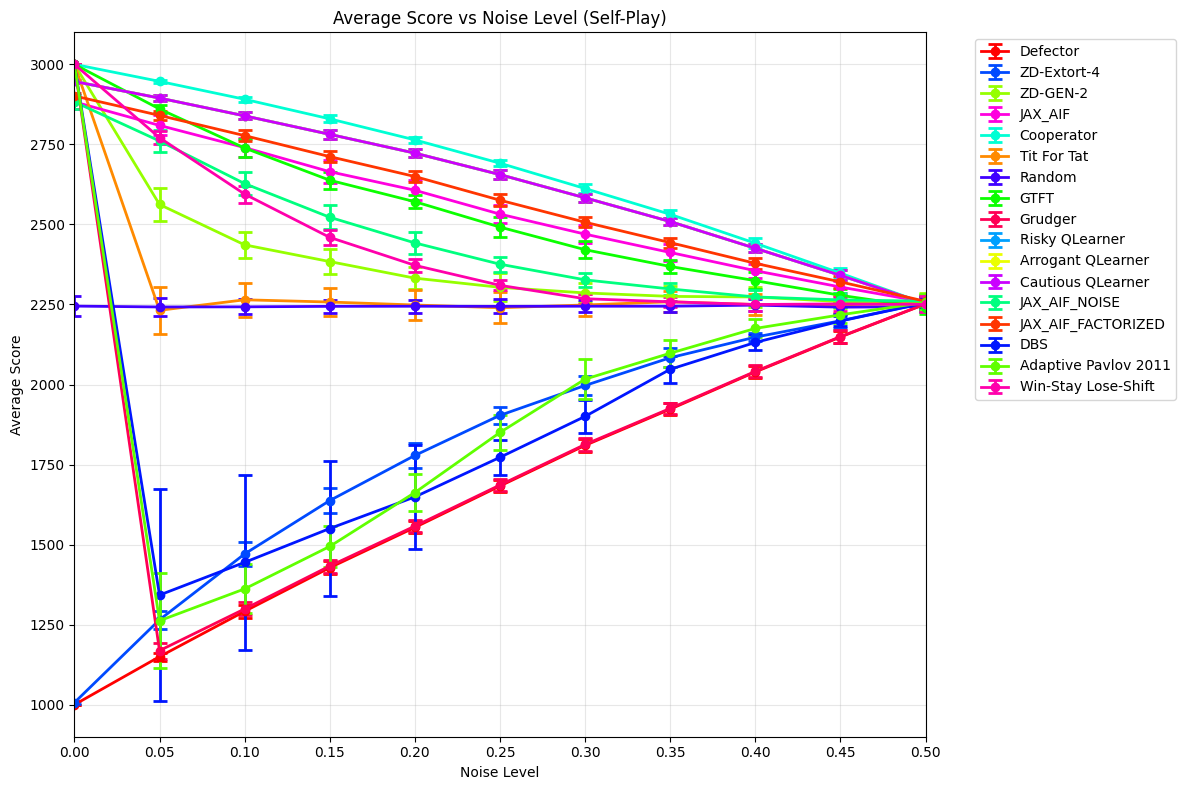


Score Summary Statistics - Percentage Change from No Noise:
Strategy            No Noise    0.05 (%)    0.1 (%)     0.15 (%)    0.2 (%)     0.25 (%)    0.3 (%)     0.35 (%)    0.4 (%)     0.45 (%)    0.5 (%)     
------------------------------------------------------------------------------------------------------------------------
Defector            1000.0      15.0        29.2        42.8        55.4        68.3        81.0        92.3        103.9       114.9       125.2       
ZD-Extort-4         1006.5      25.7        46.1        62.7        76.7        89.1        98.4        107.0       113.4       118.5       124.1       
ZD-GEN-2            3000.0      -14.6       -18.8       -20.5       -22.3       -23.2       -23.8       -24.2       -24.2       -24.7       -24.7       
JAX_AIF             2882.8      -2.6        -5.0        -7.6        -9.6        -12.2       -14.3       -16.3       -18.3       -20.1       -21.7       
Cooperator          3000.0      -1.8        -3.6     

In [6]:
# Average Score Analysis
score_results = {}

for strategy_dir in strategy_dirs:
    strategy_name = strategy_dir.name
    score_results[strategy_name] = {'noise_levels': [], 'avg_scores': [], 'score_stds': []}
    
    for noise_level in noise_levels:
        scores = []
        
        # Get all repetition directories
        repetition_dirs = [d for d in strategy_dir.iterdir() if d.is_dir() and d.name.startswith('repetition_')]
        
        for rep_dir in repetition_dirs:
            csv_file = rep_dir / f"{noise_level}.csv"
            
            if csv_file.exists():
                # Read the CSV file
                df = pd.read_csv(csv_file)
                
                # Get scores for both players and average them (since it's self-play)
                score_p1 = df.iloc[0]['Score']
                score_p2 = df.iloc[1]['Score']
                avg_score = (score_p1 + score_p2) / 2
                
                scores.append(avg_score)
        
        if scores:  # If we have data for this noise level
            score_results[strategy_name]['noise_levels'].append(noise_level)
            score_results[strategy_name]['avg_scores'].append(np.mean(scores))
            score_results[strategy_name]['score_stds'].append(np.std(scores))

# Sort score data by noise levels for proper plotting
for strategy_name, data in score_results.items():
    if data['noise_levels']:
        # Sort all lists by noise levels
        sorted_indices = sorted(range(len(data['noise_levels'])), key=lambda i: data['noise_levels'][i])
        data['noise_levels'] = [data['noise_levels'][i] for i in sorted_indices]
        data['avg_scores'] = [data['avg_scores'][i] for i in sorted_indices]
        data['score_stds'] = [data['score_stds'][i] for i in sorted_indices]

# Create score plot
plt.figure(figsize=(12, 8))

for strategy_name, data in score_results.items():
    if data['noise_levels']:  # Only plot if we have data
        plt.errorbar(data['noise_levels'], data['avg_scores'], 
                    yerr=data['score_stds'], 
                    marker='o', label=strategy_name, linewidth=2, 
                    markersize=6, capsize=5, capthick=2)

plt.xlabel('Noise Level')
plt.ylabel('Average Score')
plt.title('Average Score vs Noise Level (Self-Play)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.5)
plt.xticks(np.arange(0, 0.55, 0.05))

plt.tight_layout()
plt.show()

# Print detailed score summary statistics
print("\nScore Summary Statistics - Percentage Change from No Noise:")
print("=" * 120)

# Create header
header = f"{'Strategy':<20}"
for noise in noise_levels:
    if noise == 0:
        header += f"{'No Noise':<12}"
    else:
        header += f"{f'{noise} (%)' :<12}"
print(header)
print("-" * 120)

for strategy_name, data in score_results.items():
    if data['noise_levels'] and len(data['avg_scores']) >= 1:
        # Find the no-noise baseline score
        no_noise_score = None
        no_noise_idx = None
        
        for i, noise_level in enumerate(data['noise_levels']):
            if noise_level == 0:
                no_noise_score = data['avg_scores'][i]
                no_noise_idx = i
                break
        
        if no_noise_score is not None and no_noise_score > 0:
            row = f"{strategy_name:<20}"
            
            # For each noise level, show score and percentage change
            for target_noise in noise_levels:
                if target_noise in data['noise_levels']:
                    idx = data['noise_levels'].index(target_noise)
                    score = data['avg_scores'][idx]
                    
                    if target_noise == 0:
                        row += f"{score:<12.1f}"
                    else:
                        pct_change = ((score - no_noise_score) / no_noise_score) * 100
                        row += f"{pct_change:<12.1f}"
                else:
                    row += f"{'N/A':<12}"
            
            print(row)
        else:
            # If no baseline, just show raw scores
            row = f"{strategy_name:<20}"
            for target_noise in noise_levels:
                if target_noise in data['noise_levels']:
                    idx = data['noise_levels'].index(target_noise)
                    score = data['avg_scores'][idx]
                    row += f"{score:<12.1f}"
                else:
                    row += f"{'N/A':<12}"
            print(row)

print(f"\nNote: Percentages show change from no-noise baseline. Negative values indicate score decrease.")

# Additional analysis: Score vs CC rate correlation
print("\n\nScore vs Cooperation Rate Analysis:")
print("=" * 50)
print(f"{'Strategy':<20} {'Score-CC Correlation':<20}")
print("-" * 40)

for strategy_name in score_results.keys():
    if (strategy_name in results and strategy_name in score_results and 
        len(score_results[strategy_name]['avg_scores']) > 1):
        
        scores = score_results[strategy_name]['avg_scores']
        cc_rates = results[strategy_name]['actual_cc_rates']
        
        if len(scores) == len(cc_rates) and len(scores) > 1:
            correlation = np.corrcoef(scores, cc_rates)[0, 1]
            print(f"{strategy_name:<20} {correlation:<20.3f}")
